In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/tmp/ipykernel_57/4019413311.py:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(df_imputed[col].mean(), inplace=True)
/tmp/ipykernel_57/4019413311.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

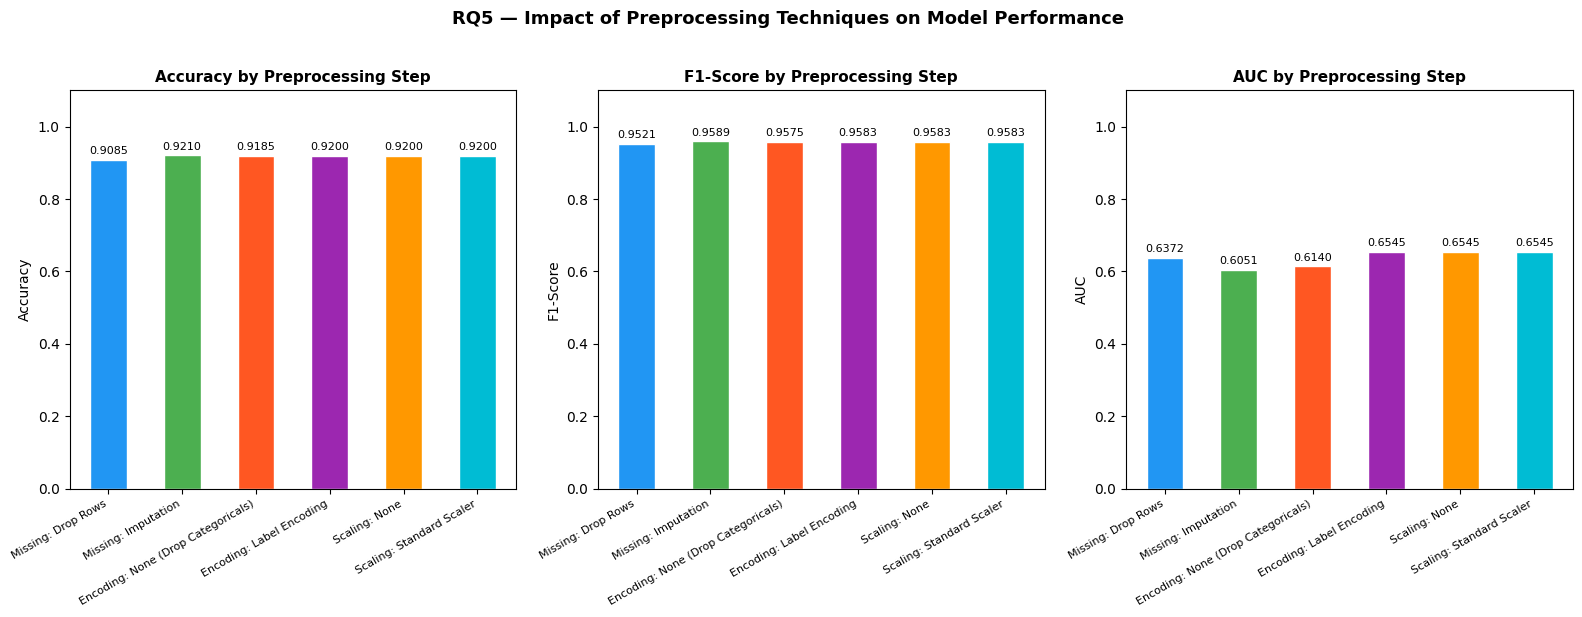

RQ5 — Preprocessing Impact Results
                Preprocessing Step  Accuracy  F1-Score    AUC
                Missing: Drop Rows    0.9085    0.9521 0.6372
               Missing: Imputation    0.9210    0.9589 0.6051
Encoding: None (Drop Categoricals)    0.9185    0.9575 0.6140
          Encoding: Label Encoding    0.9200    0.9583 0.6545
                     Scaling: None    0.9200    0.9583 0.6545
          Scaling: Standard Scaler    0.9200    0.9583 0.6545
RQ5 Complete! Files saved: RQ5_table.csv, RQ5_figure.pdf


In [2]:
# ============================================================
# RQ5: How do preprocessing techniques such as handling
# missing values, encoding categorical variables, and feature
# scaling affect model performance in predicting mental
# health outcomes?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

# --- Step 1: Load Dataset ---
df = pd.read_csv("/kaggle/input/datasets/dhrubangtalukdar/global-mental-health-and-lifestyle-survey-dataset/mental_health.csv")

# --- Step 2: Artificially Introduce Missing Values (5%) ---
# (Since your dataset has 0 missing values, we simulate to show
# the effect of handling vs not handling missing values)
df_missing = df.copy()
np.random.seed(42)
for col in df_missing.columns[:-1]:
    missing_idx = np.random.choice(df_missing.index, size=int(0.05 * len(df_missing)), replace=False)
    df_missing.loc[missing_idx, col] = np.nan

# --- Step 3: Define Evaluation Function ---
def evaluate(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = XGBClassifier(eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Preprocessing Step": label,
        "Accuracy":           round(accuracy_score(y_test, y_pred), 4),
        "F1-Score":           round(f1_score(y_test, y_pred), 4),
        "AUC":                round(roc_auc_score(y_test, y_prob), 4)
    }

results = []

# ============================================================
# EXPERIMENT 1: Missing Values — Drop vs Impute
# ============================================================

# 1A: Drop rows with missing values
df_dropped = df_missing.dropna()
cat_cols = df_dropped.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
df_dropped_enc = df_dropped.copy()
for col in cat_cols:
    df_dropped_enc[col] = le.fit_transform(df_dropped_enc[col].astype(str))
X = df_dropped_enc.drop("Has_Mental_Health_Issue", axis=1)
y = df_dropped_enc["Has_Mental_Health_Issue"]
results.append(evaluate(X, y, "Missing: Drop Rows"))

# 1B: Impute missing values (mean for numeric, mode for categorical)
df_imputed = df_missing.copy()
for col in df_imputed.columns:
    if df_imputed[col].dtype == 'object':
        df_imputed[col].fillna(df_imputed[col].mode()[0], inplace=True)
    else:
        df_imputed[col].fillna(df_imputed[col].mean(), inplace=True)
cat_cols = df_imputed.select_dtypes(include='object').columns.tolist()
df_imputed_enc = df_imputed.copy()
for col in cat_cols:
    df_imputed_enc[col] = le.fit_transform(df_imputed_enc[col].astype(str))
X = df_imputed_enc.drop("Has_Mental_Health_Issue", axis=1)
y = df_imputed_enc["Has_Mental_Health_Issue"]
results.append(evaluate(X, y, "Missing: Imputation"))

# ============================================================
# EXPERIMENT 2: Encoding — No Encoding vs Label Encoding
# ============================================================

# 2A: No encoding (drop categorical columns entirely)
df_clean = df.copy()
df_no_enc = df_clean.select_dtypes(exclude='object').copy()
X = df_no_enc.drop("Has_Mental_Health_Issue", axis=1)
y = df_no_enc["Has_Mental_Health_Issue"]
results.append(evaluate(X, y, "Encoding: None (Drop Categoricals)"))

# 2B: Label Encoding
df_le = df.copy()
cat_cols = df_le.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_le[col] = le.fit_transform(df_le[col].astype(str))
X = df_le.drop("Has_Mental_Health_Issue", axis=1)
y = df_le["Has_Mental_Health_Issue"]
results.append(evaluate(X, y, "Encoding: Label Encoding"))

# ============================================================
# EXPERIMENT 3: Scaling — No Scaling vs Standard Scaling
# ============================================================

# 3A: No scaling
df_noscale = df_le.copy()
X = df_noscale.drop("Has_Mental_Health_Issue", axis=1)
y = df_noscale["Has_Mental_Health_Issue"]
results.append(evaluate(X, y, "Scaling: None"))

# 3B: Standard Scaling
df_scaled = df_le.copy()
X_raw = df_scaled.drop("Has_Mental_Health_Issue", axis=1)
y = df_scaled["Has_Mental_Health_Issue"]
scaler = StandardScaler()
X_scaled_vals = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled_vals, columns=X_raw.columns)
results.append(evaluate(X_scaled_df, y, "Scaling: Standard Scaler"))

# ============================================================
# SAVE & PLOT
# ============================================================

# --- Save Table ---
df_results = pd.DataFrame(results)
df_results.to_csv("RQ5_table.csv", index=False)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics = ["Accuracy", "F1-Score", "AUC"]
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800', '#00BCD4']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(
        df_results["Preprocessing Step"],
        df_results[metric],
        color=colors[:len(df_results)],
        edgecolor='white',
        width=0.5
    )
    ax.set_title(f"{metric} by Preprocessing Step", fontsize=11, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_xticks(range(len(df_results)))
    ax.set_xticklabels(df_results["Preprocessing Step"], rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle("RQ5 — Impact of Preprocessing Techniques on Model Performance",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("RQ5_figure.pdf", bbox_inches='tight')
plt.show()

# --- Print Results ---
print("=" * 70)
print("RQ5 — Preprocessing Impact Results")
print("=" * 70)
print(df_results.to_string(index=False))
print("=" * 70)
print("RQ5 Complete! Files saved: RQ5_table.csv, RQ5_figure.pdf")